# 04 - Multi-Domain Feature Fusion

Concatenates the four domain matrices into the 1,002-dimensional multi-domain
representation (Algorithm 1 of the manuscript), prefixing every feature name with its
domain so it stays traceable through selection and SHAP attribution.

Run once per dataset by setting `DATASET`.

Every consistency check the algorithm specifies is **executed**, not assumed: equal row
counts across domains, identical `sample_id` ordering, and an exact join against the
frozen split manifest.

In [1]:
import sys, json
from pathlib import Path
EXPERIMENT_DIR = Path(r"/mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Experiment")
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dasfe import config as C, fusion as F, extract as EX

sns.set_theme(style="whitegrid", context="notebook")

# ----------------------------- CONFIGURE ME -----------------------------
DATASET    = "tomasov"        # "cao" or "tomasov"
SMOKE_TEST = False         # must match notebook 03
# ------------------------------------------------------------------------

feat_dir  = C.results_dir(DATASET, "03_features" + ("_smoke" if SMOKE_TEST else ""))
fuse_dir  = C.results_dir(DATASET, "04_fusion"   + ("_smoke" if SMOKE_TEST else ""))
split_dir = C.results_dir(DATASET, "01_splits")

manifest = pd.read_parquet(split_dir / "split_manifest.parquet")
print(f"dataset : {DATASET}\nfeatures: {feat_dir}\noutput  : {fuse_dir}")

dataset : tomasov
features: /mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Results/tomasov/03_features
output  : /mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Results/tomasov/04_fusion


## 1. Per-domain matrices

In [2]:
rows = []
for d in EX.DOMAIN_ORDER:
    X, names = F.load_domain(feat_dir, d)
    rows.append({"domain": d, "prefix": F.PREFIX[d], "n_windows": X.shape[0],
                 "n_features": X.shape[1], "example_feature": names[0],
                 "MB": round(X.nbytes / 1e6, 1)})
domains = pd.DataFrame(rows)
domains.loc[len(domains)] = ["MULTI", "-", domains.n_windows.iloc[0],
                             domains.n_features.sum(), "-", domains.MB.sum()]
display(domains)

assert domains.n_windows.iloc[:-1].nunique() == 1, "domains disagree on the number of windows"
assert domains.n_features.iloc[-1] == 1002, "fused dimensionality is not 1002"
print("\nPASS: all four domains aligned; fused dimensionality = 1002")

,domain,prefix,n_windows,n_features,example_feature,MB
0,time,TIME,172458,112,mean,77.3
1,freq,FREQ,172458,90,mag_mean,62.1
2,tf,TF,172458,739,stft_mean,509.8
3,spatial,SPAT,172458,61,sp_centroid,42.1
4,MULTI,-,172458,1002,-,691.3



PASS: all four domains aligned; fused dimensionality = 1002


## 2. Fuse and join to the split manifest

In [3]:
fused = F.fuse(feat_dir, manifest)
X, y = fused["X"], fused["y"]
mani = fused["manifest"]
split = mani["split"].to_numpy()

print(f"X {X.shape}   y {y.shape}")
print("\nsplit sizes:")
print(pd.Series(split).value_counts().to_string())
print("\nclass x split:")
display(pd.crosstab(mani.label, mani.split, margins=True))

# Order integrity: the manifest row i must describe feature row i.
assert (mani.sample_id.to_numpy() == fused["sample_id"]).all(), "manifest/feature misalignment"
print("\nPASS: manifest rows are aligned 1:1 with feature rows.")

X (172458, 1002)   y (172458,)

split sizes:
train    148229
val       12895
test      11334

class x split:


split,test,train,val,All
label,,,,
car,1772,25303,1934,29009
construction,2232,23041,2147,27420
fence,1983,33432,2700,38115
longboard,581,11671,1052,13304
manipulation,867,13519,1163,15549
openclose,198,5280,336,5814
regular,1111,10272,966,12349
running,929,10811,1057,12797
walk,1661,14900,1540,18101



PASS: manifest rows are aligned 1:1 with feature rows.


In [4]:
print("domain slices in the fused matrix:")
for d, sl in fused["domain_slices"].items():
    print(f"  {d:8s} columns {sl.start:4d}..{sl.stop-1:4d}")

print("\nfirst feature of each domain:")
for d, sl in fused["domain_slices"].items():
    print(f"  {fused['feature_names'][sl.start]}")

domain slices in the fused matrix:
  time     columns    0.. 111
  freq     columns  112.. 201
  tf       columns  202.. 940
  spatial  columns  941..1001

first feature of each domain:
  TIME:mean
  FREQ:mag_mean
  TF:stft_mean
  SPAT:sp_centroid


## 3. Distributional sanity

The fused matrix mixes descriptors whose natural scales differ by many orders of
magnitude (probabilities near 0-1 alongside raw spectral energies). This is harmless for
tree ensembles, and the scale-sensitive models get a `StandardScaler` **inside** their
pipeline, fitted on training folds only.

In [5]:
scales = pd.DataFrame({
    "feature": fused["feature_names"],
    "domain": sum([[d] * (sl.stop - sl.start) for d, sl in fused["domain_slices"].items()], []),
    "std": X.std(axis=0),
    "abs_max": np.abs(X).max(axis=0),
})
display(scales.groupby("domain")["std"].describe().round(4))

const = scales[scales["std"] == 0]
print(f"\nconstant features: {len(const)} / {X.shape[1]}")
if len(const):
    display(const.head(15)[["feature", "domain"]])
print("\nThese are removed by the variance threshold in notebook 05. Several are constant")
print("by construction: per-window z-scoring fixes mean=0 and std=1.")

,count,mean,std,min,25%,50%,75%,max
domain,,,,,,,,
freq,90.0,348626.7188,1.343379e+06,0.0,0.0075,0.0795,20.9654,9.314419e+06
spatial,61.0,919.7065,6.280666e+03,0.0,0.0000,0.0331,0.1991,4.860711e+04
tf,739.0,295.4519,7.523291e+03,0.0,0.0089,0.1313,0.8070,2.045007e+05
time,112.0,18.9884,7.394150e+01,0.0,0.0431,0.0948,1.0137,6.355125e+02



constant features: 37 / 1002


,feature,domain
1,TIME:std,time
2,TIME:var,time
25,TIME:zero_frac,time
26,TIME:rms,time
27,TIME:energy,time
29,TIME:mean_power,time
75,TIME:hjorth_activity,time
159,FREQ:psd_min,freq
162,FREQ:hist_b1,freq
163,FREQ:hist_b2,freq



These are removed by the variance threshold in notebook 05. Several are constant
by construction: per-window z-scoring fixes mean=0 and std=1.


/home/agx_orin/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/agx_orin/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


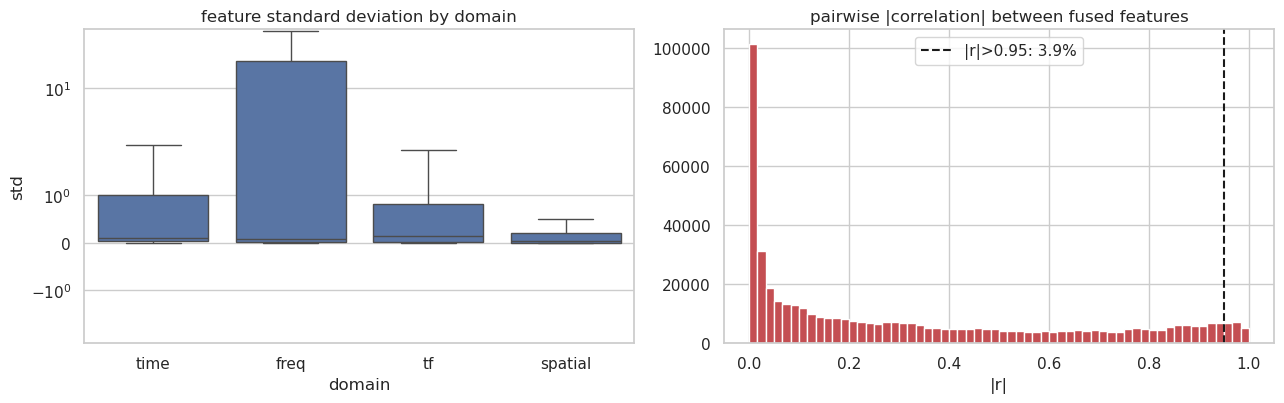

redundancy: 3.85% of feature pairs have |r| > 0.95
-> this is exactly the redundancy the ensemble feature selection targets.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

sns.boxplot(data=scales, x="domain", y="std", ax=axes[0], showfliers=False)
axes[0].set_yscale("symlog"); axes[0].set_title("feature standard deviation by domain")

corr_sample = np.corrcoef(X[np.random.default_rng(C.SEED).choice(
    len(X), size=min(3000, len(X)), replace=False)].T)
corr_sample = np.nan_to_num(corr_sample)
tri = np.abs(corr_sample[np.triu_indices_from(corr_sample, k=1)])
axes[1].hist(tri, bins=60, color="#C44E52")
axes[1].set_title("pairwise |correlation| between fused features")
axes[1].set_xlabel("|r|")
axes[1].axvline(0.95, color="k", ls="--", label=f"|r|>0.95: {100*(tri>0.95).mean():.1f}%")
axes[1].legend()

plt.tight_layout()
plt.savefig(fuse_dir / "feature_scales_and_redundancy.png", dpi=200)
plt.show()

print(f"redundancy: {100*(tri > 0.95).mean():.2f}% of feature pairs have |r| > 0.95")
print("-> this is exactly the redundancy the ensemble feature selection targets.")

## 4. Save

`X_multi.npy`, `y.npy`, `feature_names.json` and `manifest_aligned.parquet` are the only
inputs every downstream notebook needs.

In [7]:
F.save(fused, fuse_dir)
scales.to_csv(fuse_dir / "feature_scales.csv", index=False)

check = F.load(fuse_dir)
assert check["X"].shape == X.shape and (check["y"] == y).all()
print("wrote and verified:", fuse_dir)
for p in sorted(fuse_dir.iterdir()):
    print(f"  {p.name:28s} {p.stat().st_size/1e6:8.2f} MB")

wrote and verified: /mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Results/tomasov/04_fusion
  X_multi.npy                    691.21 MB
  feature_names.json               0.02 MB
  feature_scales.csv               0.04 MB
  feature_scales_and_redundancy.png     0.07 MB
  manifest_aligned.parquet         1.17 MB
  sample_ids.npy                  41.39 MB
  y.npy                            0.35 MB


---
**Next:** `05_feature_selection.ipynb` - the 8-method ensemble, fitted on training data
only and re-fitted inside every CV fold.